# Comparative Accuracy Study — Sarcasm/Irony Detection on the **iSarcasm** Dataset

This is an **independent** notebook that benchmarks the three methods from the RDS project
on the **iSarcasm** dataset (iSarcasmEval / SemEval-2022 Task 6, Subtask A — binary
intended-sarcasm detection, English), instead of TweetEval.

**The three models compared (all share the same RoBERTa classifier):**

| # | Model | Uses Qwen CoT? | Uses hashtag prior? |
|---|-------|----------------|---------------------|
| 1 | **RoBERTa-Only** baseline | no | no |
| 2 | **RoBERTa + Hashtag Prior** (ablation) | no | yes |
| 3 | **Full RDS** (RoBERTa + compressed Qwen CoT + entropy gating + hashtag prior) | yes | yes |

**How it works:**
- All three models are evaluated on the **exact same** iSarcasm test tweets, so the comparison is apples-to-apples.
- Each model's cell prints a **live running accuracy** after every tweet.
- The final cell organizes everything into a comparison table, confusion matrices, a McNemar significance test, and a grouped bar chart.

**Notes & caveats:**
- Label convention: **1 = sarcastic** (treated as the "ironic" class), **0 = non-sarcastic**.
- Model 3 replicates the pipeline that *actually executes* in tweetnlp-tokenskip.ipynb (the effective v4 fusion: alpha range 0.45–0.90, hashtag injection, no skepticism shrink — i.e. the version that produced 78.7% on TweetEval).
- These iSarcasm numbers are **not** directly comparable to the project's TweetEval numbers — this is a cross-dataset generalization study.
- Requires a **CUDA GPU** (Qwen-3B is loaded in 4-bit). Run on Colab/Kaggle, not on a local CPU box.

In [3]:
# ── Install dependencies ─────────────────────────────────────────────────────
!pip install -q transformers datasets accelerate bitsandbytes torch
!pip install -q llmlingua nltk scikit-learn matplotlib pandas

## 1. Load the iSarcasm dataset

We pull the English Subtask-A gold test set (text + binary sarcastic label) directly from the
iSarcasmEval GitHub repo. If the auto-download fails, download task_A_En_test.csv yourself from
https://github.com/iabufarha/iSarcasmEval , upload it to the Colab session, and set
raw_df = pd.read_csv("task_A_En_test.csv") manually.

In [4]:
import pandas as pd

# iSarcasmEval (SemEval-2022 Task 6) Subtask A, English — gold test set.
# Columns expected: a text/tweet column + a binary "sarcastic" label (1 = sarcastic).
CANDIDATE_URLS = [
    "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/main/test/task_A_En_test.csv",
    "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/master/test/task_A_En_test.csv",
    "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/main/CompetitionTestData/task_A_En_test.csv",
    "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/master/CompetitionTestData/task_A_En_test.csv",
]

def _load_isarcasm():
    last_err = None
    for url in CANDIDATE_URLS:
        try:
            df = pd.read_csv(url)
            print(f"Loaded iSarcasm from: {url}")
            return df
        except Exception as e:
            last_err = e
            print(f"  x failed: {url}  ({type(e).__name__})")
    raise RuntimeError(
        "Could not auto-download iSarcasm. Download task_A_En_test.csv from "
        "https://github.com/iabufarha/iSarcasmEval and upload it to this Colab "
        "session, then set:  raw_df = pd.read_csv('task_A_En_test.csv').\n"
        f"Last error: {last_err}"
    )

raw_df = _load_isarcasm()
print("Columns:", list(raw_df.columns))

# Flexible detection of the text column and the binary label column.
text_col  = next((c for c in raw_df.columns if c.lower() in ("text", "tweet", "tweets", "sentence")), None)
label_col = next((c for c in raw_df.columns if c.lower() in ("sarcastic", "label", "sarcasm")), None)
assert text_col and label_col, f"Could not find text/label columns in {list(raw_df.columns)}"
print(f"Using text column '{text_col}' and label column '{label_col}'")

clean_df = raw_df[[text_col, label_col]].dropna()
clean_df = clean_df[clean_df[label_col].apply(lambda x: str(x).strip() in ("0", "1", "0.0", "1.0"))]

isarcasm_data = [
    {"text": str(r[text_col]), "label": int(float(r[label_col]))}
    for _, r in clean_df.iterrows()
]

n_pos = sum(d["label"] for d in isarcasm_data)
print(f"\niSarcasm test set: {len(isarcasm_data)} tweets")
print(f"  Sarcastic (1)    : {n_pos}")
print(f"  Non-sarcastic (0): {len(isarcasm_data) - n_pos}")

Loaded iSarcasm from: https://raw.githubusercontent.com/iabufarha/iSarcasmEval/main/test/task_A_En_test.csv
Columns: ['text', 'sarcastic']
Using text column 'text' and label column 'sarcastic'

iSarcasm test set: 1400 tweets
  Sarcastic (1)    : 200
  Non-sarcastic (0): 1200


## 2. Load the models

- **RoBERTa** (cardiffnlp/twitter-roberta-base-irony) — shared by all three methods.
- **Qwen2.5-3B-Instruct** (4-bit) — the reasoning generator, used **only** by Full RDS.

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    AutoModelForSequenceClassification, BitsAndBytesConfig,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cpu":
    print("WARNING: no GPU detected — Full RDS (Qwen-3B) will be extremely slow.")

# RoBERTa irony classifier — shared by all three models
roberta_name  = "cardiffnlp/twitter-roberta-base-irony"
rob_tokenizer = AutoTokenizer.from_pretrained(roberta_name)
rob_model     = AutoModelForSequenceClassification.from_pretrained(roberta_name).to(device)
rob_model.eval()
print("RoBERTa loaded.")

# Qwen2.5-3B-Instruct (4-bit) — used only by Full RDS
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)
qwen_name      = "Qwen/Qwen2.5-3B-Instruct"
qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_name)
qwen_model     = AutoModelForCausalLM.from_pretrained(
    qwen_name, device_map="auto", quantization_config=bnb_config
)
print("Qwen2.5-3B loaded.")

Device: cuda


config.json:   0%|          | 0.00/705 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2.5-3B loaded.


## 3. Shared helper functions

These are copied verbatim from the project notebooks: the symbolic hashtag prior, the reasoning-entropy
budgeter, the gradient-sensitivity guardian, the CoT confidence extractor (two-pass), the RoBERTa
classifier, the entropy-gated alpha, the fused classifier, and the CoT compressor.

In [6]:
import re, math, nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
from nltk.corpus import stopwords

# ═══ Symbolic hashtag / emoji / elongation prior (identical across notebooks) ═══
_STRONG_IRONY_RE = re.compile(
    r"#(not|sarcasm|sarcastic|irony|ironic|jk|justkidding|kms|killme|"
    r"killusslow|obviously|surenot|yeahright|fml|eyeroll)\b",
    re.IGNORECASE,
)
_WEAK_IRONY_RE = re.compile(
    r"#(humor|lol|smh|seriously|really|wow|sure|totally|great|wonderful)\b",
    re.IGNORECASE,
)
_EMOJI_CONTRAST_RE = re.compile(
    r"[\U0001F60A\U0001F604\U0001F600\U0001F44D\U00002764\U0001F642\U0001F601]"
    r"\s{0,3}[|,\s]*\s{0,3}"
    r"[\U0001F612\U0001F624\U0001F621\U0001F61E\U0001F611\U0001F644\U0001F614\U0001F622]"
)
_ELONGATION_RE = re.compile(r"([a-zA-Z])\1{2,}")

def detect_explicit_irony_signal(tweet_text):
    """Returns 0.88 (strong), 0.0–0.70 (weak composite), or 0.0 (none)."""
    if _STRONG_IRONY_RE.search(tweet_text):
        return 0.88
    score = 0.0
    if _WEAK_IRONY_RE.search(tweet_text):
        score += 0.15
    if _EMOJI_CONTRAST_RE.search(tweet_text):
        score += 0.25
    if _ELONGATION_RE.search(tweet_text):
        score += 0.12
    return min(score, 0.70)

# ═══ Qwen CoT prompts ═══
STRUCTURED_PROMPT = """\
You are an expert linguist specializing in detecting irony and sarcasm in social media text.

DEFINITION: A tweet is IRONIC if there is a contrast between its literal meaning and its \
intended meaning, or if the author says the opposite of what they actually mean (often to \
mock, criticize, or be humorous). A tweet is NON-IRONIC if it is a sincere, literal statement.

KEY SIGNALS TO CHECK:
  - Does the literal meaning contradict the real-world situation?
  - Is there an exaggerated, over-the-top positive/negative tone?
  - Are there hashtags like #not, #sarcasm, #irony, #obviously that signal ironic intent?
  - Does the tweet mock or criticize something by pretending to praise it?
  - Would a reasonable reader take this at face value, or detect a hidden meaning?
  - Are there elongated words like "Loooove" or "Soooo" used sarcastically?

CONFIDENCE SCALE:
  0.0 = Absolutely certain NON-IRONIC (sincere, literal, no ambiguity at all)
  0.1 = Very likely non-ironic, tiny residual doubt
  0.3 = Probably non-ironic, some mixed signals present
  0.5 = Completely uncertain — could genuinely be either
  0.7 = Probably ironic, some mixed signals present
  0.9 = Very likely ironic, tiny residual doubt
  1.0 = Absolutely certain IRONIC (clear sarcasm/irony, no ambiguity at all)

EXAMPLES:
Tweet: "Oh great, another Monday. Just what I needed."
Reasoning: "Just what I needed" is exaggeratedly positive about something universally \
disliked. Classic sarcasm with no ambiguity.
Score: 0.95

Tweet: "Happy birthday to my best friend! Hope your day is amazing."
Reasoning: Sincere, literal birthday wish. No hidden meaning, no contrast, tone \
matches content perfectly.
Score: 0.05

Tweet: "Wow, love how my flight got cancelled on the day of my interview. Truly blessed."
Reasoning: "Truly blessed" after describing a disaster is a clear ironic inversion. \
Very high confidence.
Score: 0.92

Tweet: "This weather is something else today."
Reasoning: Ambiguous — could be genuine admiration or sarcastic complaint depending \
on context not available in the tweet alone.
Score: 0.50

Now analyze the following tweet using the same reasoning process.

Tweet: '{tweet}'

Think step by step through the KEY SIGNALS above. End your response with EXACTLY:
Score: X.XX
(a number between 0.00 and 1.00, two decimal places)"""

FORCED_VERDICT_PROMPT = """\
You analyzed a tweet and wrote this reasoning:
---
{cot_text}
---

Based solely on your own analysis above, rate your confidence that the tweet is ironic.

Output ONLY a single line in this exact format, nothing else:
Score: X.XX
(0.00 = definitely non-ironic, 0.50 = uncertain, 1.00 = definitely ironic)"""

# ═══ Reasoning entropy → dynamic compression ratio (gamma) ═══
def calculate_dynamic_gamma(logits, min_gamma=0.1, max_gamma=0.9, k=1, mu=0.5):
    probs = F.softmax(logits, dim=-1)
    epsilon = 1e-9
    entropy_tensor = -torch.sum(probs * torch.log(probs + epsilon), dim=-1)
    entropy = entropy_tensor.mean().item()
    if math.isnan(entropy):
        entropy = 0.0
    gamma_dyn = min_gamma + (max_gamma - min_gamma) / (1 + math.exp(-k * (entropy - mu)))
    return gamma_dyn, entropy

# ═══ Gradient sensitivity (local guardian) ═══
def get_gradient_sensitivity(text, rob_tokenizer, rob_model, device, target_class=1):
    inputs = rob_tokenizer(text, return_tensors="pt").to(device)
    embeddings = rob_model.roberta.embeddings.word_embeddings(inputs["input_ids"])
    embeddings.retain_grad()
    outputs = rob_model(inputs_embeds=embeddings, attention_mask=inputs["attention_mask"])
    logits = outputs.logits
    loss = F.cross_entropy(logits, torch.tensor([target_class]).to(device))
    rob_model.zero_grad()
    loss.backward()
    grad_norms = embeddings.grad.norm(dim=-1).squeeze().cpu().numpy()
    tokens = rob_tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze())
    skip_tokens = {"<s>", "</s>", "<pad>", "<unk>", ".", ",", ":", '"', "'", "?", "!"}
    sensitivity_scores = {}
    for token, grad in zip(tokens, grad_norms):
        clean_token = token.replace("Ġ", "").strip()  # strip RoBERTa's leading-space marker
        if clean_token and token not in skip_tokens and len(clean_token) > 1:
            if clean_token in sensitivity_scores:
                sensitivity_scores[clean_token] = max(sensitivity_scores[clean_token], float(grad))
            else:
                sensitivity_scores[clean_token] = float(grad)
    return sensitivity_scores

# ═══ CoT confidence extraction (two-pass) ═══
def extract_cot_confidence(cot_text):
    lower = cot_text.lower().strip()
    score_match = re.search(r"score\s*[:\-]\s*([01](?:\.\d{1,2})?|0?\.\d{1,2})", lower)
    if score_match:
        return max(0.0, min(1.0, float(score_match.group(1))))
    verdict_match = re.search(r"verdict\s*[:\-]\s*(.{1,40})", lower)
    if verdict_match:
        v = verdict_match.group(1).strip()
        if re.search(r"\b(non[- ]?ironic|not\s+ironic|not\s+sarcastic|sincere|literal|no\s+irony|no\s+sarcasm)\b", v):
            return 0.1
        if re.search(r"\b(ironic|sarcastic|sarcasm|irony)\b", v):
            return 0.9
        if re.search(r"^\s*(yes|correct|true|indeed)\s*$", v):
            return 0.9
        if re.search(r"^\s*(no|false|incorrect)\s*$", v):
            return 0.1
    sentences = re.split(r"(?<=[.!?])\s+", cot_text.strip())
    window = sentences[-3:] if len(sentences) >= 3 else sentences
    conclusion = " ".join(window).lower()
    NEGATED_IRONY = re.compile(r"\b(not|no|isn'?t|aren'?t|doesn'?t|without|lacks?|free\s+from)\b.{0,25}\b(iron(?:ic|y)|sarcas(?:m|tic))\b")
    PLAIN_IRONY = re.compile(r"\b(iron(?:ic|y)|sarcas(?:m|tic))\b")
    CONCLUDE_WORDS = re.compile(r"\b(therefore|thus|hence|so|conclude|conclusion|overall|in\s+summary|clearly|obviously|evident|appears?|seems?|suggest|indicate)\b")
    DIRECT_IRONIC = re.compile(r"\b(this|the)\s+(tweet|text|statement|post)\s+(is|appears?|seems?)\s+(?:to\s+be\s+)?(ironic|sarcastic)\b")
    DIRECT_NONIRONIC = re.compile(r"\b(this|the)\s+(tweet|text|statement|post)\s+(is|appears?|seems?)\s+(?:to\s+be\s+)?(?:not\s+|non[- ]?)(ironic|sarcastic)\b|\b(genuine|sincere|literal|straightforward|earnest)\b")
    ironic_score = nonironic_score = 0
    negated_spans = [(m.start(), m.end()) for m in NEGATED_IRONY.finditer(conclusion)]
    for s, e in negated_spans:
        ctx = conclusion[max(0, s-50):s] + conclusion[e:e+50]
        nonironic_score += 3 if CONCLUDE_WORDS.search(ctx) else 2
    for m in PLAIN_IRONY.finditer(conclusion):
        if any(s <= m.start() <= e for s, e in negated_spans):
            continue
        ctx = conclusion[max(0, m.start()-50):m.start()] + conclusion[m.end():m.end()+50]
        ironic_score += 3 if CONCLUDE_WORDS.search(ctx) else 2
    ironic_score += len(DIRECT_IRONIC.findall(conclusion)) * 2
    nonironic_score += len(DIRECT_NONIRONIC.findall(conclusion)) * 2
    total = ironic_score + nonironic_score
    if total > 0:
        return 0.15 + (ironic_score / total) * 0.70
    full_negated = len(NEGATED_IRONY.findall(lower))
    full_plain = len(PLAIN_IRONY.findall(lower)) - full_negated
    total_full = full_plain + full_negated
    if total_full > 0:
        return 0.15 + (max(0, full_plain) / total_full) * 0.70
    return 0.5

def get_forced_score(cot_text, qwen_model, qwen_tokenizer, device):
    prompt = FORCED_VERDICT_PROMPT.format(cot_text=cot_text[:800])
    inputs = qwen_tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = qwen_model.generate(**inputs, max_new_tokens=10, do_sample=False)
    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    response = qwen_tokenizer.decode(generated_ids, skip_special_tokens=True)
    return extract_cot_confidence(response)

def get_cot_signal_with_fallback(cot_text, qwen_model, qwen_tokenizer, device):
    score = extract_cot_confidence(cot_text)
    if score == 0.5:
        score = get_forced_score(cot_text, qwen_model, qwen_tokenizer, device)
    return score

# ═══ RoBERTa classifier ═══
def classify_tweet(tweet_text, rob_tokenizer, rob_model, device):
    inputs = rob_tokenizer(tweet_text, return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = rob_model(**inputs)
    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()
    return prediction, logits

def classify_tweet_prob(text):
    """Convenience wrapper: returns P(sarcastic/ironic) from RoBERTa."""
    _, logits = classify_tweet(text, rob_tokenizer, rob_model, device)
    probs = F.softmax(logits, dim=-1).squeeze().cpu()
    return probs[1].item()

# ═══ Entropy-gated alpha — matches the version that ACTUALLY RUNS in the RDS notebook (v4) ═══
def entropy_to_alpha(entropy, low_thresh=0.2, high_thresh=0.5, alpha_low=0.45, alpha_high=0.90):
    if entropy <= low_thresh:
        return alpha_low
    elif entropy >= high_thresh:
        return alpha_high
    t = (entropy - low_thresh) / (high_thresh - low_thresh)
    return alpha_low + t * (alpha_high - alpha_low)

# ═══ Fused classification (Full RDS) ═══
def fused_classify_v2(tweet_text, cot_text, entropy,
                      rob_tokenizer, rob_model,
                      qwen_model, qwen_tokenizer, device):
    _, tweet_logits = classify_tweet(tweet_text, rob_tokenizer, rob_model, device)
    tweet_probs = F.softmax(tweet_logits, dim=-1).squeeze().cpu()
    p_roberta = tweet_probs[1].item()
    p_cot = get_cot_signal_with_fallback(cot_text, qwen_model, qwen_tokenizer, device)
    p_cot = max(0.05, min(0.95, p_cot))
    hashtag_prior = detect_explicit_irony_signal(tweet_text)
    alpha = entropy_to_alpha(entropy)
    p_fused = alpha * p_roberta + (1 - alpha) * p_cot
    if hashtag_prior >= 0.85:
        alpha = min(alpha, 0.30)
        p_fused_base = alpha * p_roberta + (1 - alpha) * p_cot
        p_fused = 0.60 * p_fused_base + 0.40 * hashtag_prior
    elif hashtag_prior > 0.0:
        p_fused = 0.75 * p_fused + 0.25 * hashtag_prior
    prediction = int(p_fused >= 0.5)
    return prediction, p_roberta, p_cot, alpha, p_fused, hashtag_prior

# ═══ CoT compression ═══
CONTRASTIVE_CONNECTORS = {
    "but", "yet", "though", "although", "however", "despite", "while",
    "whereas", "still", "even", "never", "not", "no", "without", "barely",
}
def compress_cot_improved(original_text, gamma_dyn, critical_tokens):
    stop_words = set(stopwords.words("english")) - CONTRASTIVE_CONNECTORS
    words = original_text.split()
    target_length = max(5, int(len(words) * (1.0 - gamma_dyn)))
    scored_words = []
    for idx, word in enumerate(words):
        clean = word.lower().strip(".,!?\"'")
        is_critical = any(crit.lower() in clean for crit in critical_tokens if len(crit) >= 4)
        if is_critical:
            score = 1000
        elif clean in CONTRASTIVE_CONNECTORS:
            score = 500
        elif clean not in stop_words and len(clean) >= 3:
            score = 10
        else:
            score = 1
        scored_words.append((idx, word, score))
    scored_words.sort(key=lambda x: x[2], reverse=True)
    kept = sorted(scored_words[:target_length], key=lambda x: x[0])
    return " ".join(w[1] for w in kept)

print("All helper functions loaded.")

All helper functions loaded.


## 4. Build the shared evaluation set

All three models run over the **same** list of tweets so the comparison is fair.
Set NUM_SAMPLES = None for the full iSarcasm test set (slow — Full RDS runs Qwen generation per tweet),
or an integer (e.g. 200) for a quick run.

In [7]:
# Set to None for the full test set, or an int for a quick subset run.
NUM_SAMPLES = None

eval_samples = isarcasm_data if NUM_SAMPLES is None else isarcasm_data[:NUM_SAMPLES]
y_true = [d["label"] for d in eval_samples]

print(f"Evaluating all 3 models on {len(eval_samples)} iSarcasm tweets")
print(f"  Sarcastic (1)    : {sum(y_true)}")
print(f"  Non-sarcastic (0): {len(y_true) - sum(y_true)}")

# Master container — each model cell fills in its prediction list.
all_model_results = {}

Evaluating all 3 models on 1400 iSarcasm tweets
  Sarcastic (1)    : 200
  Non-sarcastic (0): 1200


## Model 1 / 3 — RoBERTa-Only baseline

Raw tweet in, single RoBERTa forward pass out. No CoT, no prior.

In [8]:
print("=" * 78)
print(" MODEL 1 / 3 — RoBERTa-Only Baseline (no CoT, no prior)")
print("=" * 78)

m1_preds, correct = [], 0
for i, d in enumerate(eval_samples):
    p_sarc = classify_tweet_prob(d["text"])
    pred   = int(p_sarc >= 0.5)
    m1_preds.append(pred)
    correct += (pred == d["label"])
    acc = correct / (i + 1) * 100
    print(f"[{i+1:04d}/{len(eval_samples)}] P(sarc)={p_sarc:.3f} | Pred={pred} | True={d['label']} "
          f"| {'OK ' if pred == d['label'] else 'X  '} [running acc {acc:5.1f}%]")

all_model_results["RoBERTa-Only"] = m1_preds
print(f"\nMODEL 1 final accuracy: {correct/len(eval_samples)*100:.2f}%  ({correct}/{len(eval_samples)})")

 MODEL 1 / 3 — RoBERTa-Only Baseline (no CoT, no prior)
[0001/1400] P(sarc)=0.311 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0002/1400] P(sarc)=0.336 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0003/1400] P(sarc)=0.979 | Pred=1 | True=1 | OK  [running acc 100.0%]
[0004/1400] P(sarc)=0.384 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0005/1400] P(sarc)=0.070 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0006/1400] P(sarc)=0.164 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0007/1400] P(sarc)=0.428 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0008/1400] P(sarc)=0.094 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0009/1400] P(sarc)=0.075 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0010/1400] P(sarc)=0.867 | Pred=1 | True=1 | OK  [running acc 100.0%]
[0011/1400] P(sarc)=0.175 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0012/1400] P(sarc)=0.902 | Pred=1 | True=0 | X   [running acc  91.7%]
[0013/1400] P(sarc)=0.143 | Pred=0 | True=0 | OK  [running acc  92.3%]
[0014/1400] P(sarc)=0

## Model 2 / 3 — RoBERTa + Symbolic Hashtag Prior (ablation)

Identical fusion logic to roberta_hashtag_ablation.ipynb: RoBERTa is blended with the symbolic
hashtag/emoji/elongation prior, with **no** Qwen CoT.

In [9]:
# Ablation fusion parameters — identical to roberta_hashtag_ablation.ipynb
OMEGA_STRONG = 0.60
ALPHA_CAP    = 0.30
OMEGA_WEAK   = 0.75

def ablation_classify(text):
    p_roberta = classify_tweet_prob(text)
    prior     = detect_explicit_irony_signal(text)
    p_base    = p_roberta
    if prior >= 0.88:                       # strong signal
        p_cot_neutral = 0.5
        p_base_capped = ALPHA_CAP * p_roberta + (1 - ALPHA_CAP) * p_cot_neutral
        p_fused = OMEGA_STRONG * p_base_capped + (1 - OMEGA_STRONG) * prior
    elif prior > 0.0:                       # weak signal
        p_fused = OMEGA_WEAK * p_base + (1 - OMEGA_WEAK) * prior
    else:                                   # no signal -> pure RoBERTa
        p_fused = p_base
    return int(p_fused >= 0.5), p_roberta, prior, p_fused

print("=" * 78)
print(" MODEL 2 / 3 — RoBERTa + Hashtag Prior (no CoT)")
print("=" * 78)

m2_preds, correct = [], 0
for i, d in enumerate(eval_samples):
    pred, p_rob, prior, p_fused = ablation_classify(d["text"])
    m2_preds.append(pred)
    correct += (pred == d["label"])
    acc = correct / (i + 1) * 100
    htag = f" | HTag={prior:.2f}" if prior > 0 else ""
    print(f"[{i+1:04d}/{len(eval_samples)}] RoBERTa={p_rob:.3f}{htag} | Fused={p_fused:.3f} "
          f"| Pred={pred} | True={d['label']} | {'OK ' if pred == d['label'] else 'X  '} "
          f"[running acc {acc:5.1f}%]")

all_model_results["RoBERTa+Hashtag"] = m2_preds
print(f"\nMODEL 2 final accuracy: {correct/len(eval_samples)*100:.2f}%  ({correct}/{len(eval_samples)})")

 MODEL 2 / 3 — RoBERTa + Hashtag Prior (no CoT)
[0001/1400] RoBERTa=0.311 | Fused=0.311 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0002/1400] RoBERTa=0.336 | Fused=0.336 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0003/1400] RoBERTa=0.979 | Fused=0.979 | Pred=1 | True=1 | OK  [running acc 100.0%]
[0004/1400] RoBERTa=0.384 | Fused=0.384 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0005/1400] RoBERTa=0.070 | Fused=0.070 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0006/1400] RoBERTa=0.164 | Fused=0.164 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0007/1400] RoBERTa=0.428 | Fused=0.428 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0008/1400] RoBERTa=0.094 | Fused=0.094 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0009/1400] RoBERTa=0.075 | Fused=0.075 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0010/1400] RoBERTa=0.867 | Fused=0.867 | Pred=1 | True=1 | OK  [running acc 100.0%]
[0011/1400] RoBERTa=0.175 | Fused=0.175 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0012/1400] RoBER

## Model 3 / 3 — Full RDS

The complete pipeline: Qwen generates a chain-of-thought, the reasoning entropy sets the dynamic
compression ratio, the gradient guardian flags critical tokens, the CoT is compressed, and finally
RoBERTa + compressed-CoT + hashtag prior are fused (the effective v4 fusion). This is the slow model.

In [10]:
def generate_cot_and_analyze(tweet):
    prompt = STRUCTURED_PROMPT.format(tweet=tweet)
    inputs = qwen_tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = qwen_model.generate(
            **inputs, max_new_tokens=120,
            return_dict_in_generate=True, output_scores=True,
        )
    gen_ids  = outputs.sequences[0][inputs["input_ids"].shape[1]:]
    cot_text = qwen_tokenizer.decode(gen_ids, skip_special_tokens=True)
    logits_stack = torch.stack(outputs.scores, dim=1).squeeze(0)
    gamma_dyn, entropy = calculate_dynamic_gamma(logits_stack)
    sens = get_gradient_sensitivity(cot_text, rob_tokenizer, rob_model, device, target_class=1)
    sorted_sens = sorted(sens.items(), key=lambda x: x[1], reverse=True)
    critical_tokens = [t[0] for t in sorted_sens if len(t[0]) >= 4][:5]
    return cot_text, entropy, gamma_dyn, critical_tokens

print("=" * 78)
print(" MODEL 3 / 3 — Full RDS (RoBERTa + compressed Qwen CoT + prior)")
print(" (replicates the pipeline that actually executes in tweetnlp-tokenskip.ipynb)")
print("=" * 78)

m3_preds, correct = [], 0
for i, d in enumerate(eval_samples):
    cot_text, entropy, gamma_dyn, crit = generate_cot_and_analyze(d["text"])
    compressed = compress_cot_improved(cot_text, gamma_dyn, crit)
    pred, p_rob, p_cot, alpha, p_fused, prior = fused_classify_v2(
        d["text"], compressed, entropy,
        rob_tokenizer, rob_model, qwen_model, qwen_tokenizer, device,
    )
    m3_preds.append(pred)
    correct += (pred == d["label"])
    acc = correct / (i + 1) * 100
    htag = f" | HTag={prior:.2f}" if prior > 0 else ""
    print(f"[{i+1:04d}/{len(eval_samples)}] RoBERTa={p_rob:.3f} | CoT={p_cot:.2f} | a={alpha:.2f}"
          f"{htag} | Fused={p_fused:.3f} | Pred={pred} | True={d['label']} "
          f"| {'OK ' if pred == d['label'] else 'X  '} [running acc {acc:5.1f}%]")

all_model_results["Full RDS"] = m3_preds
print(f"\nMODEL 3 final accuracy: {correct/len(eval_samples)*100:.2f}%  ({correct}/{len(eval_samples)})")

 MODEL 3 / 3 — Full RDS (RoBERTa + compressed Qwen CoT + prior)
 (replicates the pipeline that actually executes in tweetnlp-tokenskip.ipynb)
[0001/1400] RoBERTa=0.311 | CoT=0.67 | a=0.54 | Fused=0.478 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0002/1400] RoBERTa=0.336 | CoT=0.62 | a=0.71 | Fused=0.417 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0003/1400] RoBERTa=0.979 | CoT=0.15 | a=0.76 | Fused=0.783 | Pred=1 | True=1 | OK  [running acc 100.0%]
[0004/1400] RoBERTa=0.384 | CoT=0.15 | a=0.60 | Fused=0.291 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0005/1400] RoBERTa=0.070 | CoT=0.15 | a=0.61 | Fused=0.101 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0006/1400] RoBERTa=0.164 | CoT=0.15 | a=0.69 | Fused=0.160 | Pred=0 | True=0 | OK  [running acc 100.0%]


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[0007/1400] RoBERTa=0.428 | CoT=0.50 | a=0.57 | Fused=0.459 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0008/1400] RoBERTa=0.094 | CoT=0.15 | a=0.56 | Fused=0.119 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0009/1400] RoBERTa=0.075 | CoT=0.15 | a=0.66 | Fused=0.100 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0010/1400] RoBERTa=0.867 | CoT=0.50 | a=0.80 | Fused=0.795 | Pred=1 | True=1 | OK  [running acc 100.0%]
[0011/1400] RoBERTa=0.175 | CoT=0.25 | a=0.56 | Fused=0.208 | Pred=0 | True=0 | OK  [running acc 100.0%]
[0012/1400] RoBERTa=0.902 | CoT=0.15 | a=0.87 | Fused=0.805 | Pred=1 | True=0 | X   [running acc  91.7%]
[0013/1400] RoBERTa=0.143 | CoT=0.15 | a=0.59 | Fused=0.146 | Pred=0 | True=0 | OK  [running acc  92.3%]
[0014/1400] RoBERTa=0.955 | CoT=0.50 | a=0.72 | Fused=0.827 | Pred=1 | True=0 | X   [running acc  85.7%]
[0015/1400] RoBERTa=0.037 | CoT=0.15 | a=0.70 | Fused=0.070 | Pred=0 | True=0 | OK  [running acc  86.7%]
[0016/1400] RoBERTa=0.433 | CoT=0.15 | a=0.68 | Fused=0

## 5. Final comparative analysis

Organizes the results from all three models: a metrics table, per-model confusion matrices, McNemar
significance tests vs. Full RDS, and a grouped bar chart. Also saves two CSVs.

 COMPARATIVE RESULTS — iSarcasm test set  (N=1400)
          Model  Accuracy (%)  Macro F1  Sarcastic F1  Sarcastic Prec  Sarcastic Rec  Non-Sarc F1
       Full RDS         78.36     0.673         0.482           0.366          0.705        0.863
RoBERTa+Hashtag         74.86     0.657         0.479           0.340          0.810        0.834
   RoBERTa-Only         74.79     0.656         0.479           0.340          0.810        0.834

Best model: Full RDS  (78.36% accuracy, 0.673 macro-F1)

Confusion matrices  [TN  FP  FN  TP]   (rows=true, cols=pred):
  RoBERTa-Only       TN= 885  FP= 315  FN=  38  TP= 162
  RoBERTa+Hashtag    TN= 886  FP= 314  FN=  38  TP= 162
  Full RDS           TN= 956  FP= 244  FN=  59  TP= 141

McNemar tests (does Full RDS differ significantly from the simpler models?):
  Full RDS vs RoBERTa-Only    : RDS-only-right=81, RoBERTa-Only-only-right=31, chi2=21.438, p=0.0000  (SIGNIFICANT)
  Full RDS vs RoBERTa+Hashtag : RDS-only-right=80, RoBERTa+Hashtag-only-ri

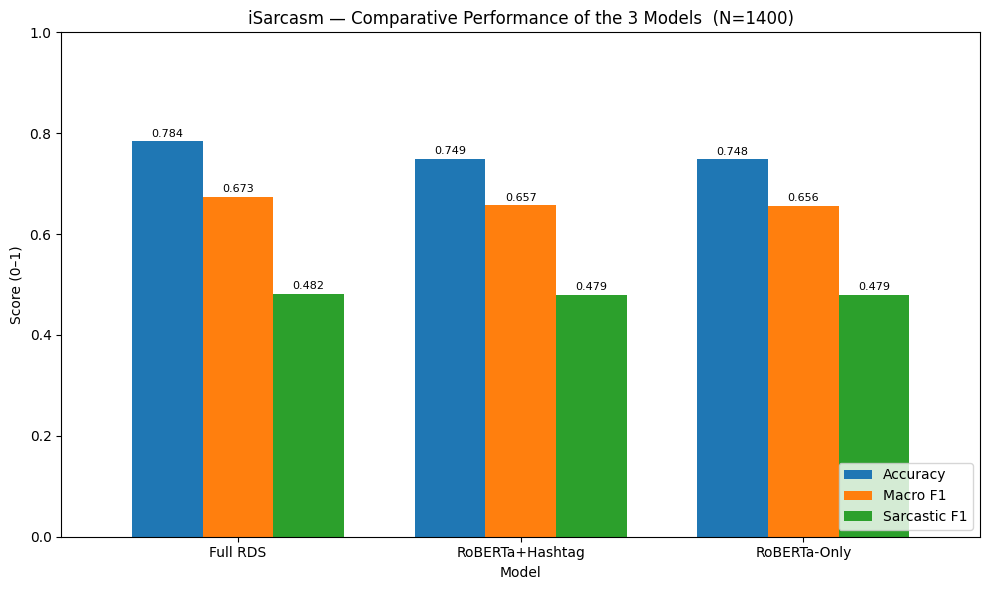


Saved: isarcasm_model_comparison.csv  and  isarcasm_per_tweet_predictions.csv


,Model,Accuracy (%),Macro F1,Sarcastic F1,Sarcastic Prec,Sarcastic Rec,Non-Sarc F1
0,Full RDS,78.36,0.673,0.482,0.366,0.705,0.863
1,RoBERTa+Hashtag,74.86,0.657,0.479,0.340,0.810,0.834
2,RoBERTa-Only,74.79,0.656,0.479,0.340,0.810,0.834


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix,
)
from IPython.display import display

assert all_model_results, "No results yet — run the three model cells above first."

# ── Metrics table ────────────────────────────────────────────────────────────
rows = []
for name, preds in all_model_results.items():
    rows.append({
        "Model"          : name,
        "Accuracy (%)"   : round(accuracy_score(y_true, preds) * 100, 2),
        "Macro F1"       : round(f1_score(y_true, preds, average="macro"), 3),
        "Sarcastic F1"   : round(f1_score(y_true, preds, pos_label=1, average="binary", zero_division=0), 3),
        "Sarcastic Prec" : round(precision_score(y_true, preds, pos_label=1, zero_division=0), 3),
        "Sarcastic Rec"  : round(recall_score(y_true, preds, pos_label=1, zero_division=0), 3),
        "Non-Sarc F1"    : round(f1_score(y_true, preds, pos_label=0, average="binary", zero_division=0), 3),
    })
summary = pd.DataFrame(rows).sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)

print("=" * 80)
print(f" COMPARATIVE RESULTS — iSarcasm test set  (N={len(y_true)})")
print("=" * 80)
print(summary.to_string(index=False))
print("=" * 80)

best = summary.iloc[0]
print(f"\nBest model: {best['Model']}  "
      f"({best['Accuracy (%)']}% accuracy, {best['Macro F1']} macro-F1)\n")

# ── Confusion matrices ───────────────────────────────────────────────────────
print("Confusion matrices  [TN  FP  FN  TP]   (rows=true, cols=pred):")
for name, preds in all_model_results.items():
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    print(f"  {name:<18} TN={tn:>4}  FP={fp:>4}  FN={fn:>4}  TP={tp:>4}")

# ── McNemar significance vs. Full RDS ────────────────────────────────────────
print("\nMcNemar tests (does Full RDS differ significantly from the simpler models?):")
try:
    from statsmodels.stats.contingency_tables import mcnemar
    def mcnemar_vs(a_preds, b_preds):
        a_only = sum(1 for a, b, t in zip(a_preds, b_preds, y_true) if a == t and b != t)
        b_only = sum(1 for a, b, t in zip(a_preds, b_preds, y_true) if a != t and b == t)
        res = mcnemar([[0, a_only], [b_only, 0]], exact=False, correction=True)
        return a_only, b_only, res.statistic, res.pvalue
    if "Full RDS" in all_model_results:
        for other in ("RoBERTa-Only", "RoBERTa+Hashtag"):
            if other in all_model_results:
                a_only, b_only, stat, p = mcnemar_vs(all_model_results["Full RDS"], all_model_results[other])
                verdict = "SIGNIFICANT" if p < 0.05 else "not significant"
                print(f"  Full RDS vs {other:<16}: RDS-only-right={a_only}, {other}-only-right={b_only}, "
                      f"chi2={stat:.3f}, p={p:.4f}  ({verdict})")
    else:
        print("  (Full RDS not run — skipped)")
except Exception as e:
    print(f"  (McNemar skipped: {e})")

# ── Grouped bar chart ────────────────────────────────────────────────────────
plot_df = summary.set_index("Model")[["Accuracy (%)", "Macro F1", "Sarcastic F1"]].copy()
plot_df["Accuracy (%)"] = plot_df["Accuracy (%)"] / 100.0
plot_df = plot_df.rename(columns={"Accuracy (%)": "Accuracy"})

ax = plot_df.plot(kind="bar", figsize=(10, 6), rot=0, width=0.75)
ax.set_title(f"iSarcasm — Comparative Performance of the 3 Models  (N={len(y_true)})")
ax.set_ylabel("Score (0–1)")
ax.set_ylim(0, 1.0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ── Save artifacts ───────────────────────────────────────────────────────────
summary.to_csv("isarcasm_model_comparison.csv", index=False)
pred_df = pd.DataFrame({
    "text": [d["text"] for d in eval_samples],
    "true": y_true,
    **all_model_results,
})
pred_df.to_csv("isarcasm_per_tweet_predictions.csv", index=False)
print("\nSaved: isarcasm_model_comparison.csv  and  isarcasm_per_tweet_predictions.csv")

display(summary)